# Results: five facets, one scheme

Reads `results/tables/results_*.csv`, produced by `scripts/28_results_tables.py`. Nothing is
recomputed here.

Two things changed relative to `03_explore_modelling_results.ipynb`, and they are why this
notebook exists separately instead of being one more section:

1. **`kfold5_window` is the only validation scheme** (`docs/10_findings.md` §1b). The numbers
   in `03` under `kfold5_owner` are **not comparable** with these. It is not that one set is
   wrong: they measure different things, and mixing them in one figure would be the error.
2. **From 9 targets to 15.** The phylogenetic facet (MPD, MNTD and the three SES) and dark
   diversity are added. Five facets: `alpha`, `beta_pa`, `beta_cover`, `phylo`, `dark`.

And three metrics instead of one. A high R2 with large bias is a model that gets the shape of
the cloud right and the level wrong — and with targets that go through Yeo-Johnson and come
back via Duan's estimator, bias is exactly where that breaks. `%RMSE` and `bias` are
normalised by the target's 1–99 range, so they are comparable across facets living on
different scales (1–50 species against 1e-3).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from biodiv import targets as tg              # noqa: E402

TABLES = ROOT / "results" / "tables"
pd.set_option("display.width", 220, "display.max_columns", 40)

full = pd.read_csv(TABLES / "results_full.csv")
facet = pd.read_csv(TABLES / "results_by_facet.csv")
best = pd.read_csv(TABLES / "results_best.csv")

FACET_ORDER = ["alpha", "beta_pa", "beta_cover", "phylo", "dark"]
COLORS = {"BASE": "#999999", "RF": "#2f6f7f", "MLP": "#dd8452",
          "C1D": "#55a868", "C2D": "#c1553b"}

print(f"{full.run_id.nunique()} runs x {full.target.nunique()} targets "
      f"= {len(full)} rows, scheme kfold5_window")
print("\nseed noise (median R2 sd) per facet:")
print(full.groupby("facet")["R2_sd"].median().round(4).to_string())

114 runs x 15 targets = 1710 rows, scheme kfold5_window

seed noise (median R2 sd) per facet:
facet
alpha         0.0124
beta_cover    0.0163
beta_pa       0.0080
dark          0.0095
phylo         0.0096


## 1. The control to look at before anything else

`B03_coords` uses **only longitude, latitude and elevation**. Zero remote sensing, zero
phenology. Under `kfold5_window` it is a brutal competitor, for a structural reason: the
scheme groups by connected component of 150 m window overlap, not by contributor, so **every
contributor is spread across folds**. Memorising the local level is free.

The column that matters is not the best model's R2: it is the difference against this
control, read against seed noise.

,B01_topo+area,B03_coords,best model,gain over coords,seed noise (sd),beats noise?
facet,,,,,,
alpha,0.299,0.490,0.494,0.004,0.012,NO
beta_pa,0.376,0.508,0.516,0.008,0.008,NO
beta_cover,0.204,0.344,0.345,0.001,0.016,NO
phylo,0.086,0.090,0.180,0.090,0.010,yes
dark,0.269,0.382,0.414,0.032,0.010,yes


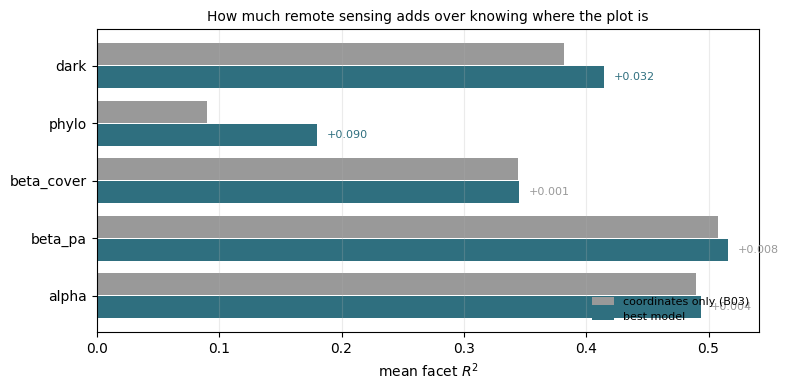

In [2]:
ctrl = (facet[facet.family == "BASE"]
        .pivot_table(index="run_id", columns="facet", values="R2")
        .reindex(columns=FACET_ORDER))
best_model = facet[facet.family != "BASE"].groupby("facet")["R2"].max().reindex(FACET_ORDER)
noise = full.groupby("facet")["R2_sd"].median().reindex(FACET_ORDER)

summary = pd.DataFrame({
    "B01_topo+area": ctrl.loc["B01_topo-area"],
    "B03_coords": ctrl.loc["B03_coords"],
    "best model": best_model,
    "gain over coords": best_model - ctrl.loc["B03_coords"],
    "seed noise (sd)": noise,
})
summary["beats noise?"] = np.where(
    summary["gain over coords"] > 2 * summary["seed noise (sd)"], "yes", "NO")
display(summary.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(FACET_ORDER))
ax.barh(y + 0.2, ctrl.loc["B03_coords"], height=0.38, color="#999999",
        label="coordinates only (B03)")
ax.barh(y - 0.2, best_model, height=0.38, color="#2f6f7f", label="best model")
for i, f in enumerate(FACET_ORDER):
    d = best_model[f] - ctrl.loc["B03_coords", f]
    ax.text(best_model[f] + 0.008, i - 0.2, f"+{d:.3f}", va="center", fontsize=8,
            color="#2f6f7f" if d > 2 * noise[f] else "#999999")
ax.set_yticks(y); ax.set_yticklabels(FACET_ORDER)
ax.set_xlabel("mean facet $R^2$")
ax.set_title("How much remote sensing adds over knowing where the plot is", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

**Read it this way.** On `alpha`, `beta_pa` and `beta_cover` the best model ties with the
coordinates: the gains are of the order of seed noise. The two new facets are the only ones
where remote sensing adds something geography does not give — and on `phylo` the model
**doubles** the control.

That inverts the expectation the project started from. The facets added last, almost as a
complement, are the ones that justify the predictor.

## 2. The three metrics, per facet

`R2` says how much variance is explained; `%RMSE` how much error remains in units of the
target's range; `|bias|` whether the error is centred. All three for the best model of each
target.

,facet,target,run_id,family,index,n,R2,R2_sd,%RMSE,bias %,spearman
0,alpha,hill_q0,B03_coords,BASE,NaN,1082,0.663,0.003,12.483,-0.178,0.788
1,alpha,hill_q1,MLP06_curve_kndvi,MLP,kndvi,1082,0.461,0.016,14.860,-0.084,0.656
2,alpha,hill_q2,MLP06_curve_kndvi,MLP,kndvi,1082,0.408,0.022,14.481,-0.163,0.584
3,beta_pa,lcbd_pa,B03_coords,BASE,NaN,1082,0.507,0.004,17.574,0.126,0.700
4,beta_pa,pcoa1_pa,RF03_curve-topo-area_evi,RF,evi,1082,0.574,0.005,15.973,-0.051,0.770
5,beta_pa,pcoa2_pa,B03_coords,BASE,NaN,1082,0.504,0.004,16.422,0.277,0.733
6,beta_cover,lcbd_cover,B03_coords,BASE,NaN,546,0.411,0.007,20.403,-0.797,0.616
7,beta_cover,pcoa1_cover,RF03_curve-topo-area_nbr_v2,RF,nbr,546,0.394,0.009,21.985,2.618,0.655
8,beta_cover,pcoa2_cover,RF06_curve_all-topo-area,RF,NaN,546,0.340,0.010,19.398,0.340,0.610
9,phylo,mntd,C1D01_curve1d_kndvi_ctxclim-topo-area,C1D,kndvi,969,0.211,0.011,18.599,0.129,0.438


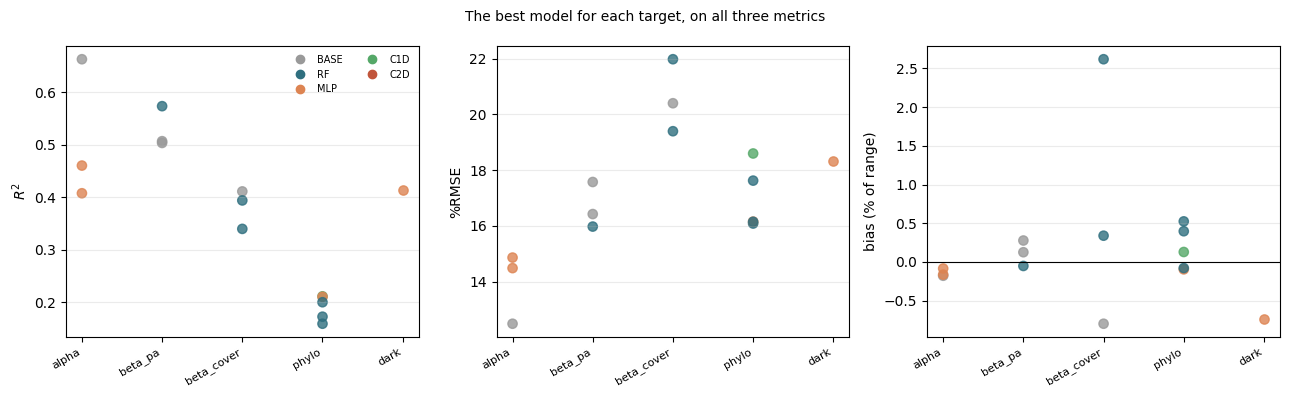

Bias stays under 2 % of range almost everywhere: the trimmed Duan estimator is doing
its job. The exceptions are in beta_cover, the 546-plot stratum — half the data and
twice the per-fold variance.


In [3]:
b = best.copy()
b["%RMSE"] = 100 * b["nRMSE"]
b["bias %"] = 100 * b["nBias"]
b["facet"] = pd.Categorical(b["facet"], FACET_ORDER, ordered=True)
display(b.sort_values(["facet", "target"])[
    ["facet", "target", "run_id", "family", "index", "n", "R2", "R2_sd",
     "%RMSE", "bias %", "spearman"]].round(3).reset_index(drop=True))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, lab) in zip(axes, [("R2", "$R^2$"), ("%RMSE", "%RMSE"),
                                 ("bias %", "bias (% of range)")]):
    for i, f in enumerate(FACET_ORDER):
        d = b[b.facet == f]
        ax.scatter([i] * len(d), d[col], s=45, alpha=0.8,
                   color=[COLORS.get(x, "#8172b3") for x in d.family])
    ax.set_xticks(range(len(FACET_ORDER)))
    ax.set_xticklabels(FACET_ORDER, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(lab)
    ax.grid(axis="y", alpha=0.25)
    if col == "bias %":
        ax.axhline(0, color="k", lw=0.8)
axes[0].legend([plt.Line2D([], [], marker="o", ls="", color=c) for c in COLORS.values()],
               COLORS.keys(), fontsize=7, frameon=False, ncol=2)
fig.suptitle("The best model for each target, on all three metrics", fontsize=10)
plt.tight_layout(); plt.show()

print("Bias stays under 2 % of range almost everywhere: the trimmed Duan estimator is doing\n"
      "its job. The exceptions are in beta_cover, the 546-plot stratum — half the data and\n"
      "twice the per-fold variance.")

## 3. Model families

The comparison that decides whether the deep-learning apparatus was worth it.

facet,alpha,beta_pa,beta_cover,phylo,dark
family,,,,,
BASE,0.249,0.282,0.150,0.075,0.217
RF,0.411,0.496,0.321,0.162,0.372
MLP,0.420,0.463,0.295,0.160,0.354
C1D,0.357,0.427,0.231,0.154,0.286
C2D,0.344,0.414,0.245,0.142,0.304


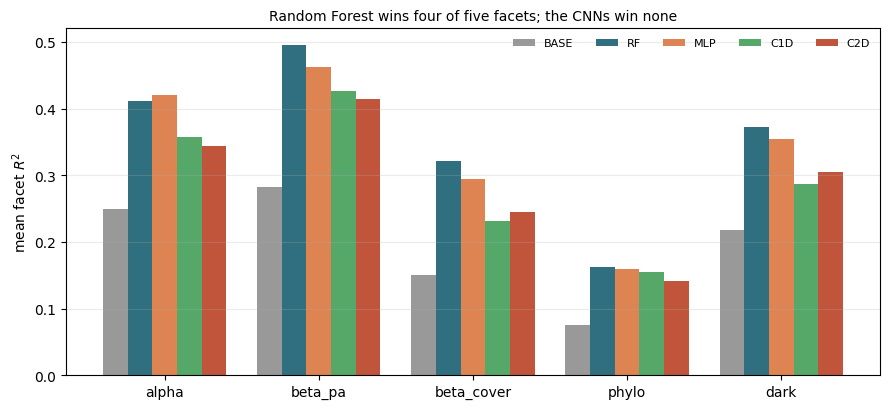

This matches the expectation in docs/11_next_steps.md §3: with 1,082 plots the
architecture is not the lever. Screening result 4 already anticipated it — X14 with
511 columns falls below X17 with 87.


In [4]:
fam = (facet.pivot_table(index="family", columns="facet", values="R2", aggfunc="mean")
       .reindex(columns=FACET_ORDER)
       .reindex(["BASE", "RF", "MLP", "C1D", "C2D"]))
display(fam.round(3))

fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.16
for k, family in enumerate(fam.index):
    ax.bar(np.arange(len(FACET_ORDER)) + (k - 2) * w, fam.loc[family], width=w,
           color=COLORS[family], label=family)
ax.set_xticks(range(len(FACET_ORDER))); ax.set_xticklabels(FACET_ORDER)
ax.set_ylabel("mean facet $R^2$")
ax.set_title("Random Forest wins four of five facets; the CNNs win none", fontsize=10)
ax.legend(fontsize=8, frameon=False, ncol=5)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

print("This matches the expectation in docs/11_next_steps.md §3: with 1,082 plots the\n"
      "architecture is not the lever. Screening result 4 already anticipated it — X14 with\n"
      "511 columns falls below X17 with 87.")

## 4. Vegetation indices — and why the raw average lies

The matrix design is **unbalanced**: kNDVI ran with 32 CNN configurations and the other
indices with 3, because stage 4a screened the eleven substrates on kNDVI and stage 4b only
expanded the best ones over the rest. Averaging carelessly charges kNDVI with the bad
substrates the others never ran, and leaves it last.

The correct comparison is **within each family**, and for C2D restricted to the substrates
that did run on all five indices.

runs per index and family — the imbalance that has to be corrected:


family,C1D,C2D,MLP,RF
index,,,,
evi,2,3,2,6
kndvi,3,37,6,6
nbr,2,3,2,6
ndvi,2,3,2,6
savi,2,3,2,6


family,C1D,C2D,MLP,RF,mean
index,,,,,
kndvi,0.284,0.320,0.349,0.360,0.328
ndvi,0.289,0.323,0.330,0.356,0.325
nbr,0.293,0.323,0.333,0.349,0.325
savi,0.272,0.310,0.318,0.346,0.312
evi,0.273,0.306,0.318,0.346,0.310


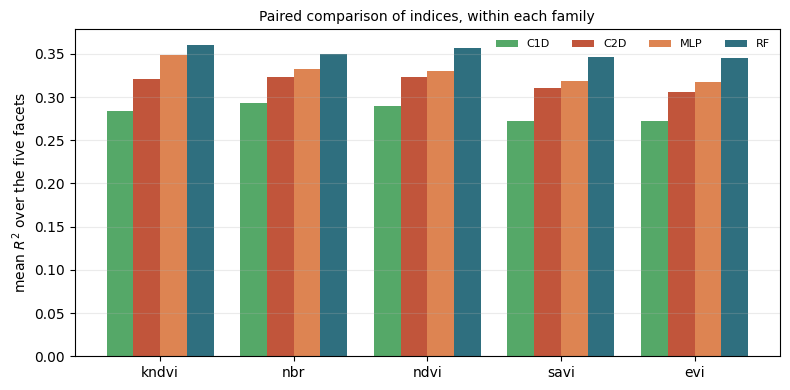

spread between the best and worst index, within each family:
family
C1D    0.021
C2D    0.017
MLP    0.032
RF     0.015

seed noise: 0.011. For RF the spread across indices is the same
order of magnitude: the index barely matters. kNDVI wins or ties in all four families.


In [5]:
ix = facet[facet["index"].notna()].copy()
ABLATION = r"_(?:w[ACX]|calendar|nglobal|nperSample|film|patch|none|mixup|noaug|ctx)"
ix["is_ablation"] = ix.run_id.str.contains(ABLATION)

print("runs per index and family — the imbalance that has to be corrected:")
display(ix.pivot_table(index="index", columns="family", values="run_id", aggfunc="nunique"))

base = ix[~ix.is_ablation]
# within C2D, only the substrates present in all five indices
c2 = base[base.family == "C2D"]
shared = c2.groupby("substrate")["index"].nunique()
c2 = c2[c2.substrate.isin(shared[shared == 5].index)]
fair = pd.concat([base[base.family != "C2D"], c2])

tab = fair.pivot_table(index="index", columns="family", values="R2", aggfunc="mean")
tab["mean"] = tab.mean(axis=1)
display(tab.round(3).sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
t = tab.drop(columns="mean").loc[tab.sort_values("mean", ascending=False).index]
x = np.arange(len(t))
for k, family in enumerate(t.columns):
    ax.bar(x + (k - (len(t.columns) - 1) / 2) * 0.2, t[family], width=0.2,
           color=COLORS.get(family, "#8172b3"), label=family)
ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel("mean $R^2$ over the five facets")
ax.set_title("Paired comparison of indices, within each family", fontsize=10)
ax.legend(fontsize=8, frameon=False, ncol=4)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

spread = (tab.drop(columns="mean").max() - tab.drop(columns="mean").min()).round(3)
print("spread between the best and worst index, within each family:")
print(spread.to_string())
print(f"\nseed noise: {full.R2_sd.median():.3f}. For RF the spread across indices is the same\n"
      "order of magnitude: the index barely matters. kNDVI wins or ties in all four families.")

## 5. Each facet in detail

The ten best runs of each facet with the three metrics. `R2_min` and `R2_max` are across the
targets **within** the facet: a facet with a wide spread is not well summarised by its mean.

In [6]:
for f in FACET_ORDER:
    d = facet[facet.facet == f].head(10).copy()
    d["%RMSE"] = 100 * d["nRMSE"]
    d["|bias|"] = 100 * d["nBias_abs"]
    print(f"\n===== {f}  ({', '.join(tg.FACETS[f])})")
    display(d[["run_id", "family", "index", "substrate", "R2", "R2_min", "R2_max",
               "%RMSE", "|bias|", "spearman"]].round(3).reset_index(drop=True))


===== alpha  (hill_q0, hill_q1, hill_q2)


,run_id,family,index,substrate,R2,R2_min,R2_max,%RMSE,|bias|,spearman
0,MLP06_curve_kndvi,MLP,kndvi,tabular,0.494,0.408,0.613,14.242,0.320,0.672
1,B03_coords,BASE,NaN,NaN,0.490,0.373,0.663,14.208,0.504,0.662
2,C1D01_curve1d_kndvi_ctxclim-topo-area,C1D,kndvi,curve1d,0.465,0.368,0.594,14.640,0.728,0.646
3,C2D02_serpentine_kndvi_ctxclim-topo-area,C2D,kndvi,serpentine,0.464,0.370,0.590,14.655,0.545,0.651
4,MLP07_curve_all,MLP,NaN,tabular,0.462,0.382,0.557,14.720,0.693,0.666
5,C2D01_reshape_kndvi_ctxclim-topo-area,C2D,kndvi,reshape,0.455,0.363,0.580,14.775,0.510,0.645
6,RF03_curve-topo-area_kndvi,RF,kndvi,NaN,0.447,0.332,0.594,14.858,1.423,0.650
7,MLP05c_curve_kndvi,MLP,kndvi,tabular,0.442,0.347,0.574,14.955,0.228,0.640
8,RF03_curve-topo-area_evi,RF,evi,NaN,0.441,0.306,0.629,14.870,1.596,0.635
9,RF04_lsp-curve-topo-area_kndvi,RF,kndvi,NaN,0.441,0.322,0.595,14.932,1.501,0.647



===== beta_pa  (lcbd_pa, pcoa1_pa, pcoa2_pa)


,run_id,family,index,substrate,R2,R2_min,R2_max,%RMSE,|bias|,spearman
0,RF06_curve_all-topo-area,RF,NaN,NaN,0.516,0.490,0.563,16.876,0.177,0.719
1,RF01_lsp-topo-area_kndvi,RF,kndvi,NaN,0.510,0.481,0.564,16.968,0.114,0.716
2,RF02_lsp-qc-topo-area_kndvi,RF,kndvi,NaN,0.509,0.479,0.562,16.992,0.120,0.717
3,RF04_lsp-curve-topo-area_kndvi,RF,kndvi,NaN,0.508,0.484,0.553,17.010,0.322,0.715
4,B03_coords,BASE,NaN,NaN,0.508,0.504,0.513,17.025,0.154,0.719
5,RF03_curve-topo-area_evi,RF,evi,NaN,0.508,0.462,0.574,17.001,0.060,0.715
6,RF03_curve-topo-area_kndvi,RF,kndvi,NaN,0.507,0.478,0.558,17.018,0.307,0.714
7,RF04_lsp-curve-topo-area_evi,RF,evi,NaN,0.507,0.457,0.571,17.016,0.057,0.715
8,RF04_lsp-curve-topo-area_savi,RF,savi,NaN,0.504,0.453,0.574,17.052,0.054,0.711
9,RF03_curve-topo-area_savi,RF,savi,NaN,0.503,0.455,0.573,17.070,0.071,0.710



===== beta_cover  (lcbd_cover, pcoa1_cover, pcoa2_cover)


,run_id,family,index,substrate,R2,R2_min,R2_max,%RMSE,|bias|,spearman
0,MLP06_curve_kndvi,MLP,kndvi,tabular,0.345,0.279,0.386,21.162,1.314,0.608
1,RF06_curve_all-topo-area,RF,NaN,NaN,0.344,0.321,0.372,21.234,1.787,0.601
2,B03_coords,BASE,NaN,NaN,0.344,0.247,0.411,21.159,1.642,0.591
3,RF05_lsp_all-topo-area,RF,NaN,NaN,0.335,0.313,0.370,21.371,1.731,0.599
4,RF04_lsp-curve-topo-area_evi,RF,evi,NaN,0.333,0.300,0.389,21.378,1.893,0.587
5,MLP07_curve_all,MLP,NaN,tabular,0.331,0.261,0.376,21.401,1.345,0.606
6,RF04_lsp-curve-topo-area_nbr,RF,nbr,NaN,0.329,0.284,0.393,21.438,1.515,0.594
7,RF04_lsp-curve-topo-area_savi,RF,savi,NaN,0.328,0.294,0.388,21.463,1.946,0.579
8,RF02_lsp-qc-topo-area_kndvi,RF,kndvi,NaN,0.328,0.293,0.361,21.499,1.818,0.584
9,RF03_curve-topo-area_kndvi,RF,kndvi,NaN,0.327,0.288,0.367,21.502,1.773,0.578



===== phylo  (mpd, mntd, ses_pd, ses_mpd, ses_mntd)


,run_id,family,index,substrate,R2,R2_min,R2_max,%RMSE,|bias|,spearman
0,RF02_lsp-qc-topo-area_kndvi,RF,kndvi,NaN,0.180,0.152,0.202,17.036,0.222,0.370
1,RF04_lsp-curve-topo-area_kndvi,RF,kndvi,NaN,0.178,0.151,0.209,17.057,0.242,0.371
2,MLP06_curve_kndvi,MLP,kndvi,tabular,0.178,0.143,0.210,17.049,0.182,0.391
3,RF04_lsp-curve-topo-area_ndvi,RF,ndvi,NaN,0.178,0.159,0.199,17.058,0.304,0.371
4,C1D01_curve1d_kndvi_ctxclim-topo-area,C1D,kndvi,curve1d,0.177,0.137,0.211,17.061,0.199,0.393
5,MLP01_lsp_nbr,MLP,nbr,tabular,0.176,0.132,0.205,17.074,0.237,0.381
6,C2D01_reshape_nbr,C2D,nbr,reshape,0.175,0.142,0.197,17.083,0.326,0.361
7,RF01_lsp-topo-area_kndvi,RF,kndvi,NaN,0.174,0.144,0.196,17.094,0.250,0.367
8,RF03_curve-topo-area_kndvi_v2,RF,kndvi,NaN,0.174,0.120,0.198,17.090,0.192,0.368
9,RF03_curve-topo-area_kndvi,RF,kndvi,NaN,0.174,0.129,0.205,17.097,0.222,0.372



===== dark  (dark_n)


,run_id,family,index,substrate,R2,R2_min,R2_max,%RMSE,|bias|,spearman
0,MLP06_curve_kndvi,MLP,kndvi,tabular,0.414,0.414,0.414,18.331,0.739,0.665
1,MLP07_curve_all,MLP,NaN,tabular,0.394,0.394,0.394,18.643,0.745,0.654
2,RF06_curve_all-topo-area,RF,NaN,NaN,0.394,0.394,0.394,18.653,0.573,0.641
3,RF02_lsp-qc-topo-area_ndvi,RF,ndvi,NaN,0.391,0.391,0.391,18.690,0.693,0.643
4,RF01_lsp-topo-area_ndvi,RF,ndvi,NaN,0.391,0.391,0.391,18.700,0.603,0.642
5,RF05_lsp_all-topo-area,RF,NaN,NaN,0.390,0.390,0.390,18.705,0.737,0.641
6,RF01_lsp-topo-area_kndvi,RF,kndvi,NaN,0.388,0.388,0.388,18.733,0.598,0.640
7,RF02_lsp-qc-topo-area_kndvi,RF,kndvi,NaN,0.388,0.388,0.388,18.745,0.678,0.641
8,RF04_lsp-curve-topo-area_ndvi,RF,ndvi,NaN,0.385,0.385,0.385,18.781,0.727,0.640
9,MLP05c_curve_kndvi,MLP,kndvi,tabular,0.383,0.383,0.383,18.810,1.090,0.640


## 6. Target by target

The facet mean hides that targets within a facet do not behave alike. The phylogenetic SES
metrics, by construction, discount richness — and what is left is the hardest thing to see
from phenology.

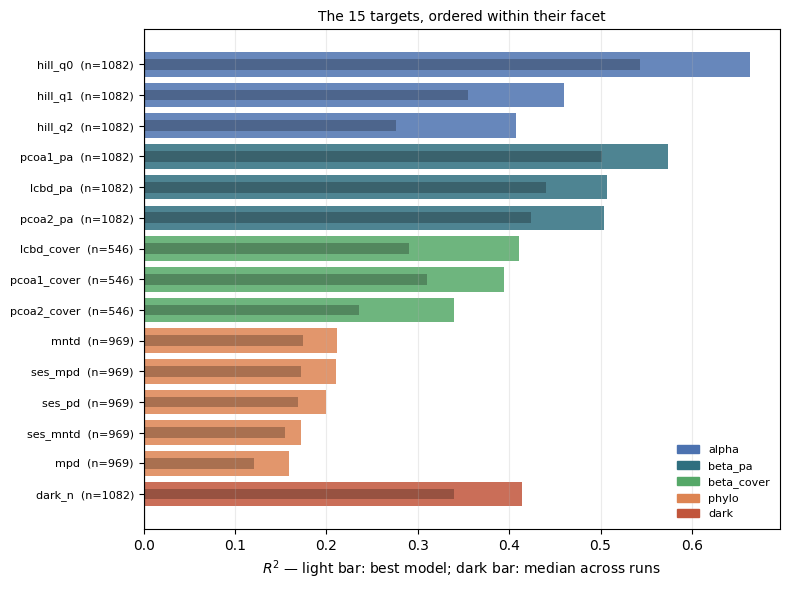

,facet,target,best_R2,median_R2,n
0,alpha,hill_q0,0.663,0.543,1082
1,alpha,hill_q1,0.461,0.355,1082
2,alpha,hill_q2,0.408,0.276,1082
3,beta_pa,pcoa1_pa,0.574,0.502,1082
4,beta_pa,lcbd_pa,0.507,0.440,1082
5,beta_pa,pcoa2_pa,0.504,0.424,1082
6,beta_cover,lcbd_cover,0.411,0.290,546
7,beta_cover,pcoa1_cover,0.394,0.311,546
8,beta_cover,pcoa2_cover,0.340,0.236,546
9,phylo,mntd,0.211,0.174,969


In [7]:
per_target = (full.groupby(["facet", "target"])
              .agg(best_R2=("R2", "max"), median_R2=("R2", "median"), n=("n", "first"))
              .reset_index())
per_target["facet"] = pd.Categorical(per_target["facet"], FACET_ORDER, ordered=True)
per_target = per_target.sort_values(["facet", "best_R2"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(per_target))[::-1]
cmap = dict(zip(FACET_ORDER, ["#4c72b0", "#2f6f7f", "#55a868", "#dd8452", "#c1553b"]))
ax.barh(y, per_target.best_R2, color=[cmap[f] for f in per_target.facet], alpha=0.85)
ax.barh(y, per_target.median_R2, color="k", alpha=0.25, height=0.35)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.target}  (n={r.n})" for r in per_target.itertuples()], fontsize=8)
ax.set_xlabel("$R^2$ — light bar: best model; dark bar: median across runs")
ax.axvline(0, color="k", lw=0.8)
ax.set_title("The 15 targets, ordered within their facet", fontsize=10)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=cmap[f]) for f in FACET_ORDER],
          FACET_ORDER, fontsize=8, frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

display(per_target.round(3).reset_index(drop=True))

## 7. GDM — the alternative to the PCoA axes

`scripts/21_run_gdm.py`. Instead of reducing composition to axes and predicting each plot's
position, it models the **dissimilarity between every pair** as a function of environmental
distance. The relevant comparison is the two *ceilings*: the rho a model would reach if it
predicted perfectly the 2 axes the project models today, and the 8.

,geography only,GDM,GDM + geo,SGDM,RF on 8 axes,ceiling: 2 true axes,ceiling: 8 true axes
spec,,,,,,,
clim+topo,0.408,0.491,0.502,0.481,0.381,0.318,0.398
composite_all+topo,0.408,0.519,0.536,0.497,0.382,0.318,0.398
curve+clim+topo,0.408,0.548,0.549,0.538,0.378,0.318,0.398
curve+gm+obscomp_all+seas_all+contrast+topo,0.408,0.528,0.542,0.476,0.375,0.318,0.398
curve+topo,0.408,0.525,0.541,0.514,0.383,0.318,0.398
gm+obscomp_all+seas_all+contrast+topo,0.408,0.524,0.538,0.475,0.372,0.318,0.398
gm+topo,0.408,0.527,0.542,0.501,0.373,0.318,0.398


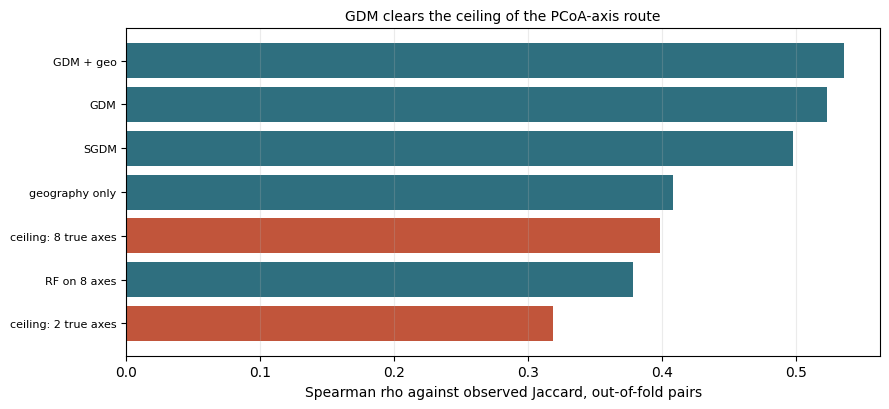

The 2 axes the project models today carry 13.8 % of the compositional
variance. Predicting them perfectly has a ceiling no architecture crosses;
GDM clears it because it chases a better-defined objective. This is the open
decision in docs/11_next_steps.md §4.


In [8]:
GDM = TABLES / "gdm_comparison.csv"
if GDM.exists():
    g = pd.read_csv(GDM)
    g = g[g.scheme == "kfold5_window"]
    if len(g):
        cols = {"geo_rho": "geography only", "gdm_rho": "GDM", "gdm_geo_rho": "GDM + geo",
                "sgdm_rho": "SGDM", "rf_axes_rho": "RF on 8 axes",
                "oracle2_rho": "ceiling: 2 true axes",
                "oracle_rho": "ceiling: 8 true axes"}
        tab = g.groupby("spec")[list(cols)].mean().rename(columns=cols)
        display(tab.round(3))

        fig, ax = plt.subplots(figsize=(9, 4.2))
        m = tab.mean().sort_values()
        bar_colors = ["#c1553b" if "ceiling" in k else "#2f6f7f" for k in m.index]
        ax.barh(range(len(m)), m.values, color=bar_colors)
        ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index, fontsize=8)
        ax.set_xlabel("Spearman rho against observed Jaccard, out-of-fold pairs")
        ax.set_title("GDM clears the ceiling of the PCoA-axis route", fontsize=10)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout(); plt.show()

        print("The 2 axes the project models today carry 13.8 % of the compositional\n"
              "variance. Predicting them perfectly has a ceiling no architecture crosses;\n"
              "GDM clears it because it chases a better-defined objective. This is the open\n"
              "decision in docs/11_next_steps.md §4.")
    else:
        print("gdm_comparison.csv has no kfold5_window rows yet — the queue is still running")
else:
    print("does not exist yet — run scripts/run_window_queue.sh")

## 8. What has to be said when reporting this

- **The `alpha` R2 under `kfold5_window` is not the one under `kfold5_owner`.** It goes from
  -0.02 to +0.49. The model did not improve: the scheme spreads each contributor across folds
  and getting the local level right is free again. The number always travels with that
  caveat attached.
- **Dark diversity is the facet with the least contributor confounding** in the project
  (R2 by `Owner` of 0.22 against 0.70 for log-richness, `docs/12` §8). Its R2 is more solid
  than alpha's even though it is lower.
- **`pd_faith` and `completeness` are absent on purpose.** They correlate +0.948 and +0.988
  with richness; including them would have produced two "results" that are `hill_q0` under
  another name. They sit in `tg.DROPPED` with the number that justifies it.